<h1 style = "color : teal">Normalization

In [1]:
# import required libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [13]:
# loading data and converting it to dataframe 

df = pd.read_csv('wine_data.csv', usecols = [0,1,2], names = ['Classlabel', 'Alcohol', 'Malicacid'])
df

,Classlabel,Alcohol,Malicacid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

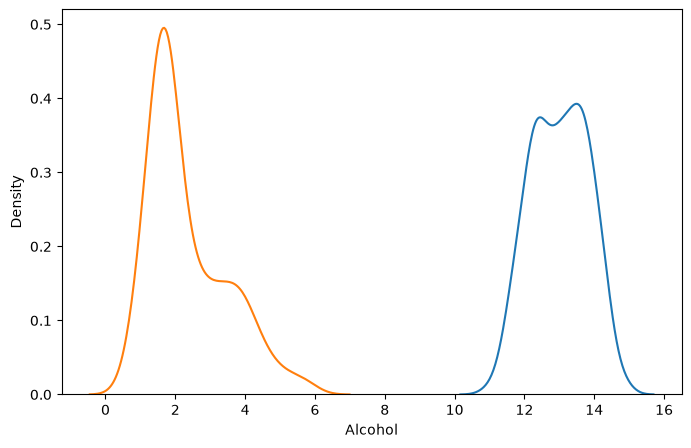

In [14]:
# getting the idea of the distribution 

plt.figure(figsize = (8,5))
sns.kdeplot(data = df, x = 'Alcohol')
sns.kdeplot(data = df, x = 'Malicacid')

<Axes: xlabel='Alcohol', ylabel='Malicacid'>

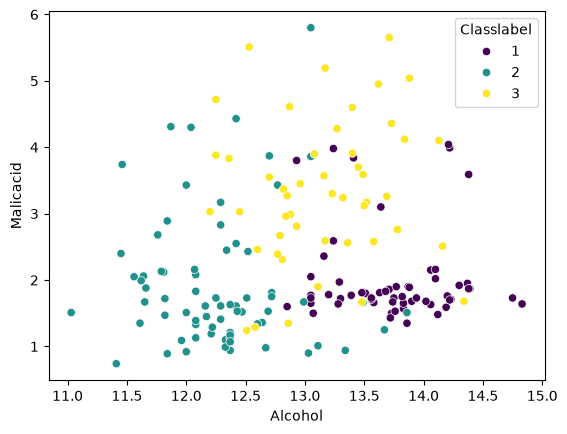

In [18]:
sns.scatterplot(data = df, x = 'Alcohol', y = 'Malicacid', hue = 'Classlabel', palette = 'viridis')

<h2 style = "color : teal">Train Test Split

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Classlabel', axis = 1), df['Classlabel'], test_size = 0.3, random_state = 0)

X_test.shape, X_train.shape

((54, 2), (124, 2))

<h2 style = "color : teal">Applying Normalization using MinMaxScaler()

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](2,)","[14.75, 5.65]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](2,)","[11.03, 0.89]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](2,)","[3.72,4.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Alcohol','Malicacid']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](2,)","[-2.97,-0.19]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,124


In [21]:
# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Converting the scaled values to data frame

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)
X_train_scaled

,Alcohol,Malicacid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252
...,...,...
119,0.212366,0.174370
120,0.360215,0.058824
121,0.373656,0.151261
122,0.771505,0.165966


In [27]:
# Stastical details before scaling

np.round(X_train.describe(), 1)

,Alcohol,Malicacid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [28]:
# Stastical details after scaling

np.round(X_train_scaled.describe(), 1)

,Alcohol,Malicacid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


<h2 style = "color : teal">Before and After Scaling</h2>

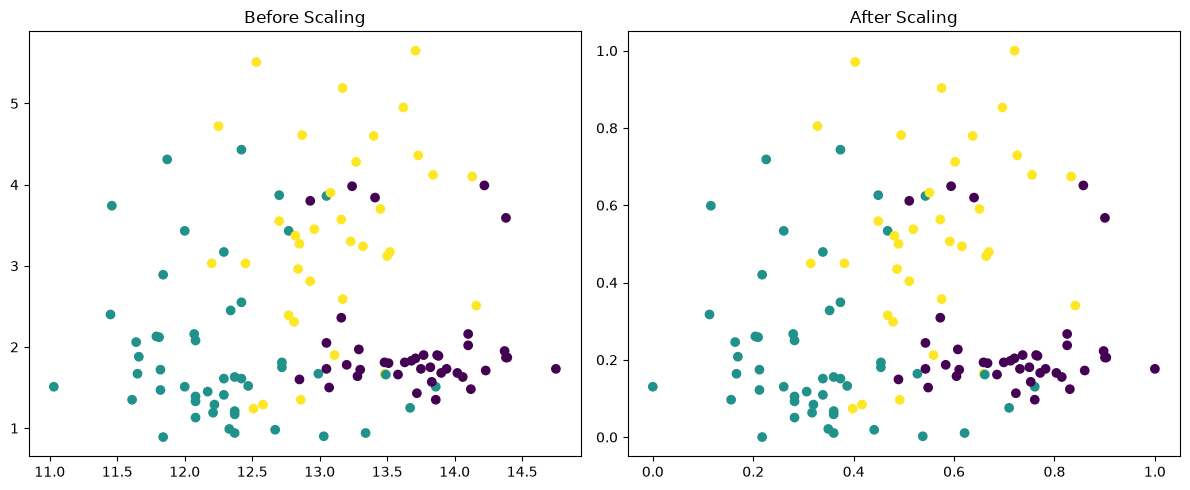

In [33]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# Before Scaling
ax1.scatter(X_train['Alcohol'], X_train['Malicacid'], c = y_train)
ax1.set_title("Before Scaling")

# After scaling
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malicacid'], c = y_train)
ax2.set_title("After Scaling")

plt.tight_layout()
plt.show()

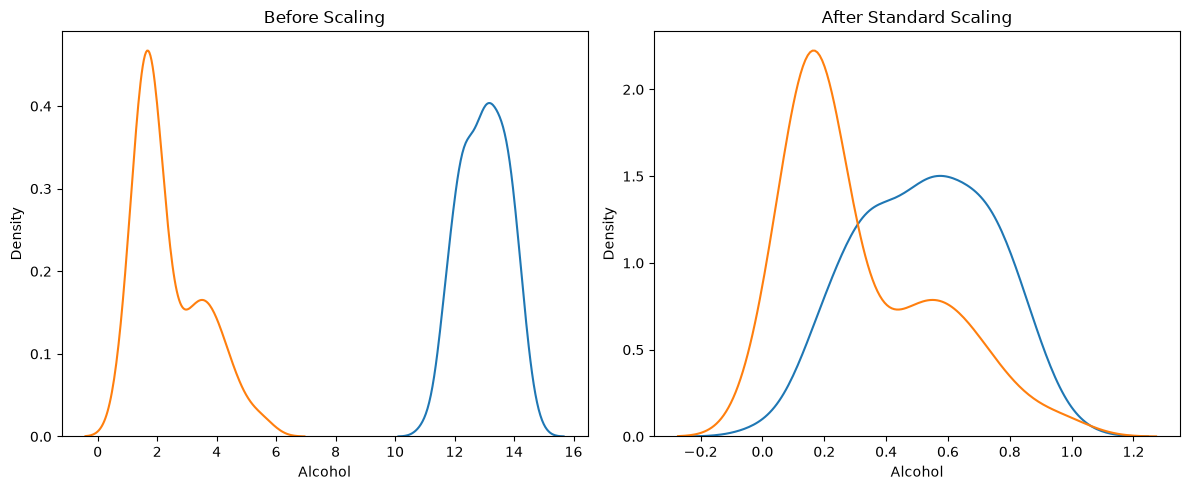

In [43]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax = ax1)
sns.kdeplot(X_train['Malicacid'], ax = ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax = ax2)
sns.kdeplot(X_train_scaled['Malicacid'], ax = ax2)

plt.tight_layout()
plt.show()

<h2 style = "color : teal">Changes in Distribution</h2>

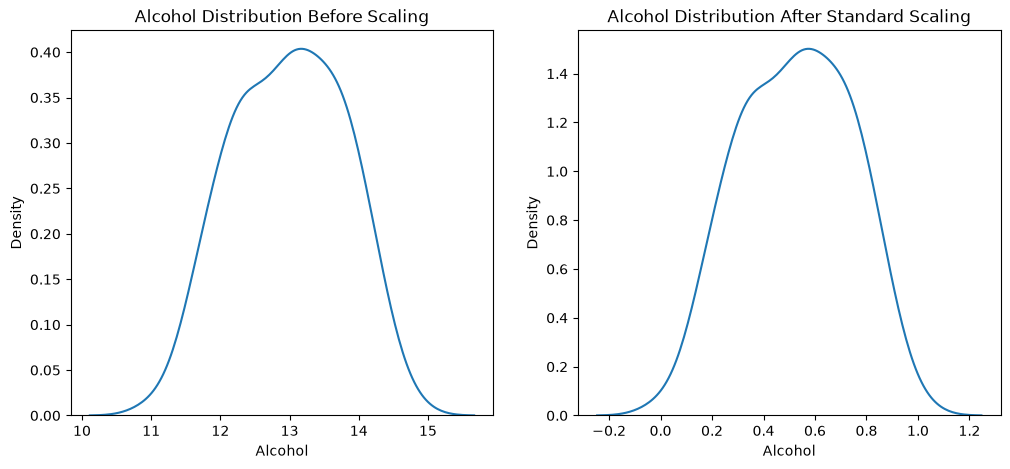

In [44]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax = ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax = ax2)
plt.show()